<h1 style="text-align:center;">Song Success Prediction Model</h1>
<h2 style="text-align:center;">Modeling</h2>

<h4 style="text-align:center;">by Cameron Hicks</h3>

The Song Success Prediction Model project aims to create a Machine Learning Model that can predict the success and popularity of a song in the early or pre-release stages of production. The objective of this notebook is to train 3 Machine Learning Models and ultimately determine the best model to select as the final output of this project. In the steps below each model will be trained on the training data sets, then their accuracy will be tested using the test data sets. All three models will be objectively compared to make the final determination.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.dummy import DummyRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score, 
    precision_score,
    recall_score,
    f1_score,
    auc,
    roc_curve,
    roc_auc_score,
    RocCurveDisplay,
    classification_report,
    ConfusionMatrixDisplay,
    mean_absolute_error, 
    mean_squared_error, 
    r2_score
)

# Import Data

In [7]:
X_train_scaled = pd.read_csv('../Data/X_train_scaled.csv')
X_test_scaled = pd.read_csv('../Data/X_test_scaled.csv')
y_train = pd.read_csv('../Data/y_train.csv')
y_test = pd.read_csv('../Data/y_test.csv')

# Dummy Model for Comparison

In [8]:
# Mean Strategy

dummy_mean = DummyRegressor(strategy="mean")
dummy_mean.fit(X_train_scaled, y_train)

y_pred_dummy_mean = dummy_mean.predict(X_test_scaled)

dummy_mean_metrics = {
    "Model": "Dummy (Mean)",
    "R2": r2_score(y_test, y_pred_dummy_mean),
    "MAE": mean_absolute_error(y_test, y_pred_dummy_mean),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_dummy_mean))
}

dummy_mean_metrics

{'Model': 'Dummy (Mean)',
 'R2': -9.721828204201088e-05,
 'MAE': 11.512125572056322,
 'RMSE': 14.826212214308708}

In [9]:
# Median Strategy

dummy_median = DummyRegressor(strategy="median")
dummy_median.fit(X_train_scaled, y_train)

y_pred_dummy_median = dummy_median.predict(X_test_scaled)

dummy_median_metrics = {
    "Model": "Dummy (Median)",
    "R2": r2_score(y_test, y_pred_dummy_median),
    "MAE": mean_absolute_error(y_test, y_pred_dummy_median),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_dummy_median))
}

dummy_median_metrics

{'Model': 'Dummy (Median)',
 'R2': -0.007458681985762272,
 'MAE': 11.455652992760873,
 'RMSE': 14.880678177238332}

# Model 1 - Linear Regression

In [10]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

In [11]:
print("LINEAR REGRESSION RESULTS")

r2 = r2_score(y_test, y_pred_lr)
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

LINEAR REGRESSION RESULTS
R2: -0.0009241185239940997
MAE: 11.51579485554882
RMSE: 14.832340251228054


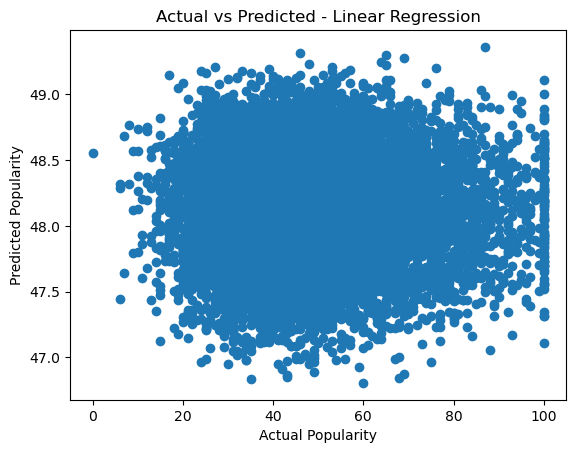

In [12]:
plt.scatter(y_test, y_pred_lr)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted - Linear Regression")
plt.show()

# Model 2 - Random Forest Regression

In [13]:
rf = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=1
)

rf.fit(X_train_scaled, y_train)

y_pred_rf = rf.predict(X_test_scaled)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [14]:
print("\nRANDOM FOREST RESULTS")

r2 = r2_score(y_test, y_pred_rf)
mae = mean_absolute_error(y_test, y_pred_rf)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


RANDOM FOREST RESULTS
R2: -0.013790719326364442
MAE: 11.639644223412395
RMSE: 14.927368637220148


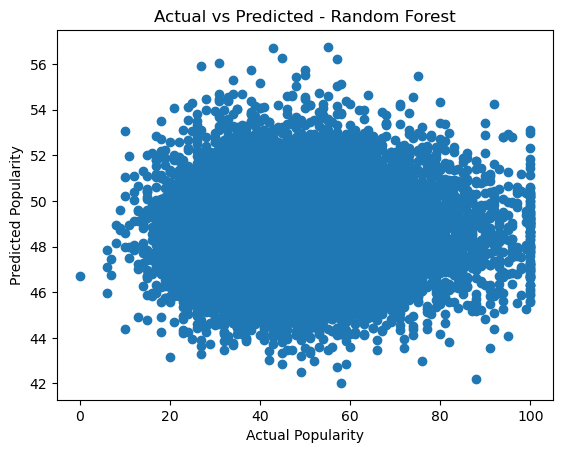

In [15]:
plt.scatter(y_test, y_pred_rf)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted - Random Forest")
plt.show()

## Second Random Forest with GridSearchCV

In [16]:
# Find the best parameters for Random Forest Regression

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [10, 20, None]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)


/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)
/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,),

{'max_depth': 10, 'n_estimators': 400}


In [17]:
rf2 = RandomForestRegressor(
    n_estimators=400,
    max_depth=10,
    random_state=42,
    n_jobs=1
)

rf2.fit(X_train_scaled, y_train)

y_pred_rf2 = rf2.predict(X_test_scaled)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [18]:
print("RANDOM FOREST IMPROVED PARAMS RESULTS")

r2 = r2_score(y_test, y_pred_rf2)
mae = mean_absolute_error(y_test, y_pred_rf2)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_rf2))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

RANDOM FOREST IMPROVED PARAMS RESULTS
R2: -0.0007531316120570342
MAE: 11.51900881888315
RMSE: 14.831073299852772


After performing Hyperparameter Tuning using GridSearchCV, the R2 score for Random Forest slightly improved, however is still negative.

# Model 3 - Gradient Boosting Regression

In [19]:
gb = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

gb.fit(X_train_scaled, y_train)

y_pred_gb = gb.predict(X_test_scaled)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [20]:
print("GRADIENT BOOSTING RESULTS")
print("-------------------------")

r2 = r2_score(y_test, y_pred_gb)
mae = mean_absolute_error(y_test, y_pred_gb)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)


GRADIENT BOOSTING RESULTS
-------------------------
R2: -0.0031296167717906886
MAE: 11.53068418245182
RMSE: 14.848672508268308


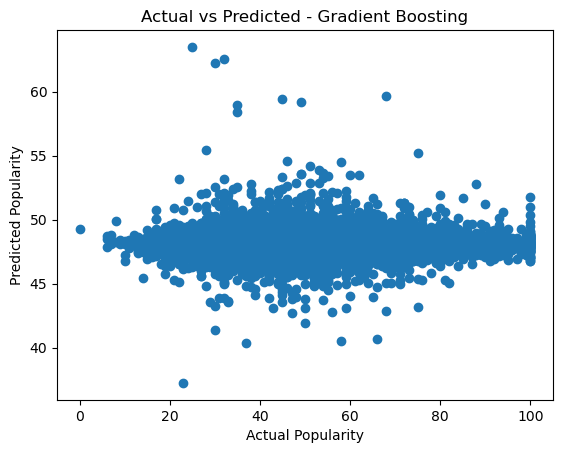

In [21]:
plt.scatter(y_test, y_pred_gb)
plt.xlabel("Actual Popularity")
plt.ylabel("Predicted Popularity")
plt.title("Actual vs Predicted - Gradient Boosting")
plt.show()

## Second Gradient Boosting

In [22]:
# Find the best parameters for Random Forest Regression

param_grid = {
    'n_estimators': [200, 400],
    'max_depth': [10, 20, None]
}

grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?
/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y w

{'max_depth': 10, 'n_estimators': 200}


In [23]:
gb2 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=10,
    random_state=42
)

gb2.fit(X_train_scaled, y_train)

y_pred_gb2 = gb2.predict(X_test_scaled)

/opt/anaconda3/lib/python3.12/site-packages/sklearn/ensemble/_gb.py:668: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)  # TODO: Is this still required?


In [24]:
print("GRADIENT BOOSTING RESULTS")
print("-------------------------")

r2 = r2_score(y_test, y_pred_gb2)
mae = mean_absolute_error(y_test, y_pred_gb2)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_gb2))

print("R2:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

GRADIENT BOOSTING RESULTS
-------------------------
R2: -0.04452808996273161
MAE: 11.78845164357776
RMSE: 15.15197218099655


After performing HyperParamater tuning with the Gradient Boosting Regressor, the R2 score declined further into the negative.

# Model Comparison

## Initial Model Comp

In [26]:
# Initial Model Results

results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest", "Gradient Boosting"],
    "R2": [
        r2_score(y_test, y_pred_lr),
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb)
    ],
    "MAE": [
        mean_absolute_error(y_test, y_pred_lr),
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_lr)),
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb))
    ]
})

print("Initial Model Results with First Params")
results

Initial Model Results with First Params


,Model,R2,MAE,RMSE
0,Linear Regression,-0.000924,11.515795,14.832340
1,Random Forest,-0.013791,11.639644,14.927369
2,Gradient Boosting,-0.003130,11.530684,14.848673


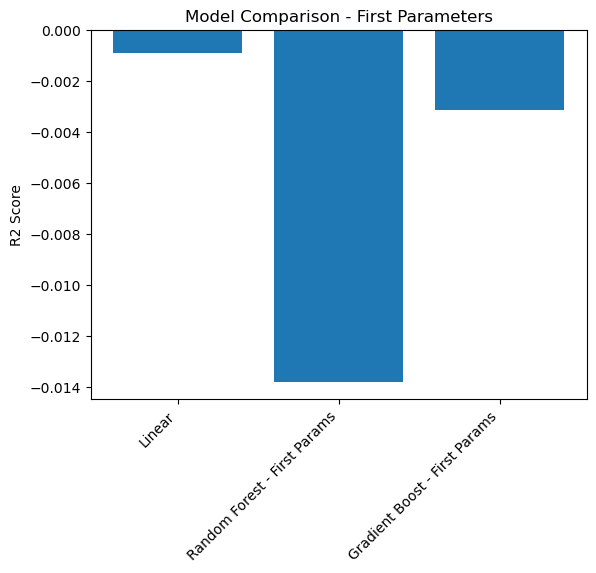

In [27]:
models = ["Linear", "Random Forest - First Params", "Gradient Boost - First Params"]
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf),
    r2_score(y_test, y_pred_gb)
]

plt.bar(models, r2_scores)
plt.ylabel("R2 Score")
plt.title("Model Comparison - First Parameters")
plt.xticks(rotation=45, ha='right')
plt.show()

In [33]:
# Initial Model Comp to Dummy Model

lr_metrics = {
    "Model": "Linear Regression",
    "R2": r2_score(y_test, y_pred_lr),
    "MAE": mean_absolute_error(y_test, y_pred_lr),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lr))
}

rf_metrics = {
    "Model": "Random Forest",
    "R2": r2_score(y_test, y_pred_rf),
    "MAE": mean_absolute_error(y_test, y_pred_rf),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf))
}

gb_metrics = {
    "Model": "Gradient Boosting",
    "R2": r2_score(y_test, y_pred_gb),
    "MAE": mean_absolute_error(y_test, y_pred_gb),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_gb))
}

results_df = pd.DataFrame([
    dummy_mean_metrics,
    dummy_median_metrics,
    lr_metrics,
    rf_metrics,
    gb_metrics
]).sort_values(by="RMSE")

print("Initial Model Comp to Dummy Model")
results_df

Initial Model Comp to Dummy Model


,Model,R2,MAE,RMSE
0,Dummy (Mean),-0.000097,11.512126,14.826212
2,Linear Regression,-0.000924,11.515795,14.832340
4,Gradient Boosting,-0.003130,11.530684,14.848673
1,Dummy (Median),-0.007459,11.455653,14.880678
3,Random Forest,-0.013791,11.639644,14.927369


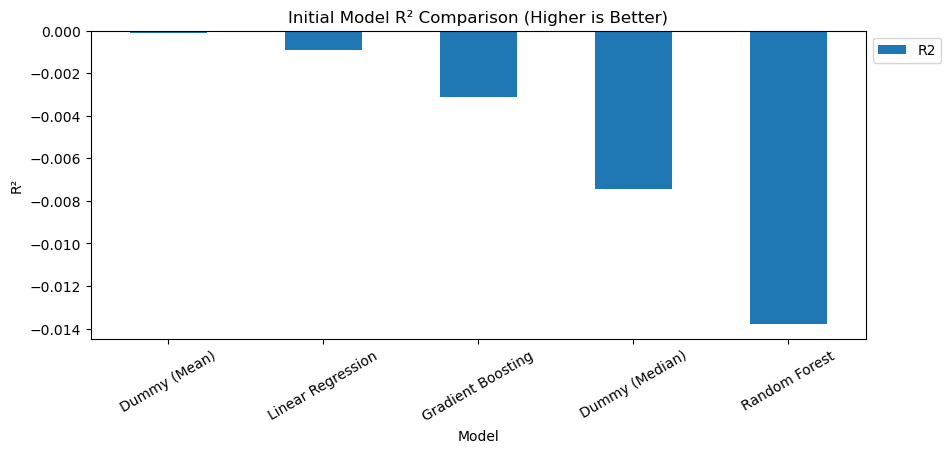

In [48]:
ax = results_df.set_index("Model")[["R2"]].plot(kind="bar", figsize=(10,4))
ax.set_title("Initial Model R² Comparison (Higher is Better)")
ax.set_ylabel("R²")
ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
ax.tick_params(axis='x', rotation=30)

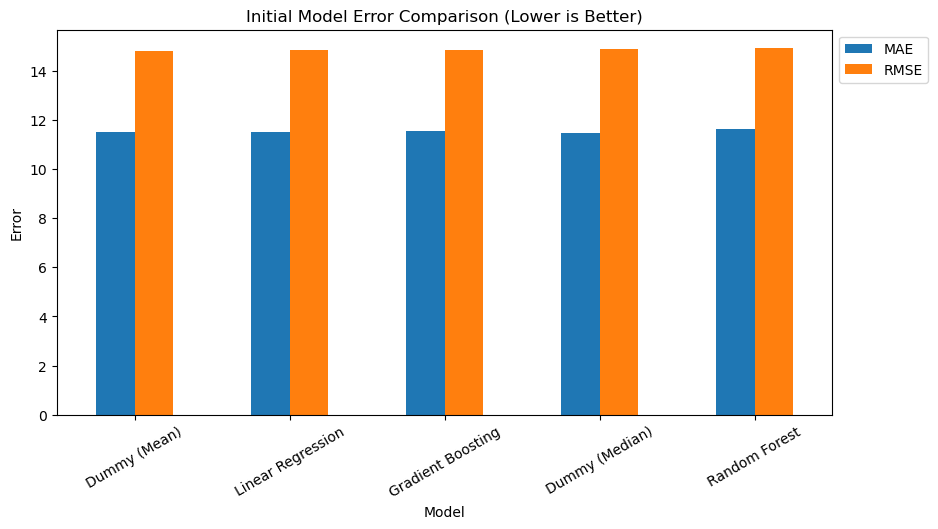

In [34]:
ax = results_df.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar", figsize=(10,5))
ax.set_title("Initial Model Error Comparison (Lower is Better)")
ax.set_ylabel("Error")
ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
ax.tick_params(axis='x', rotation=30)

## Best Params Model Comp

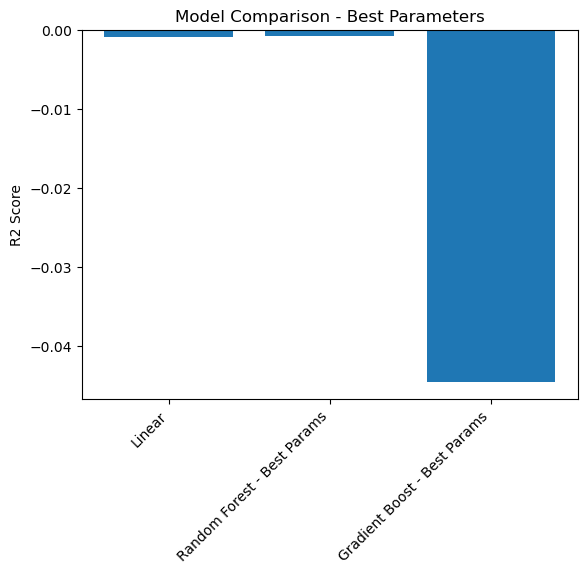

In [35]:
models = ["Linear", "Random Forest - Best Params", "Gradient Boost - Best Params"]
r2_scores = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_rf2),
    r2_score(y_test, y_pred_gb2)
]

plt.bar(models, r2_scores)
plt.ylabel("R2 Score")
plt.title("Model Comparison - Best Parameters")
plt.xticks(rotation=45, ha='right')
plt.show()

In [40]:
# Best Params Model Comp to Dummy Model

# Initial Model Comp to Dummy Model

lr_metrics_2 = {
    "Model": "Linear Regression",
    "R2": r2_score(y_test, y_pred_lr),
    "MAE": mean_absolute_error(y_test, y_pred_lr),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_lr))
}

rf_metrics_2 = {
    "Model": "Random Forest - BP",
    "R2": r2_score(y_test, y_pred_rf2),
    "MAE": mean_absolute_error(y_test, y_pred_rf2),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_rf2))
}

gb_metrics_2 = {
    "Model": "Gradient Boosting - BP",
    "R2": r2_score(y_test, y_pred_gb2),
    "MAE": mean_absolute_error(y_test, y_pred_gb2),
    "RMSE": np.sqrt(mean_squared_error(y_test, y_pred_gb2))
}

results_df_2 = pd.DataFrame([
    dummy_mean_metrics,
    dummy_median_metrics,
    lr_metrics_2,
    rf_metrics_2,
    gb_metrics_2
]).sort_values(by="RMSE")

print("Best Params Model Comp to Dummy Model")
results_df_2

Best Params Model Comp to Dummy Model


,Model,R2,MAE,RMSE
0,Dummy (Mean),-0.000097,11.512126,14.826212
3,Random Forest - BP,-0.000753,11.519009,14.831073
2,Linear Regression,-0.000924,11.515795,14.832340
1,Dummy (Median),-0.007459,11.455653,14.880678
4,Gradient Boosting - BP,-0.044528,11.788452,15.151972


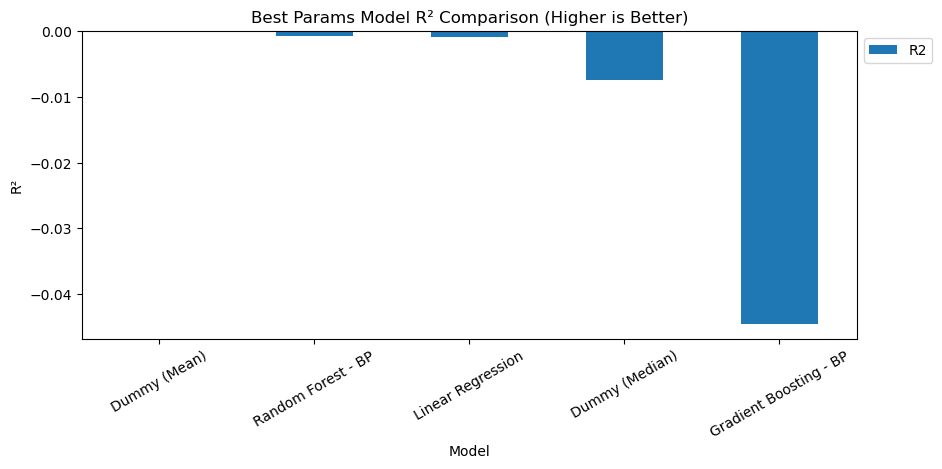

In [49]:
ax = results_df_2.set_index("Model")[["R2"]].plot(kind="bar", figsize=(10,4))
ax.set_title("Best Params Model R² Comparison (Higher is Better)")
ax.set_ylabel("R²")
ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
ax.tick_params(axis='x', rotation=30)

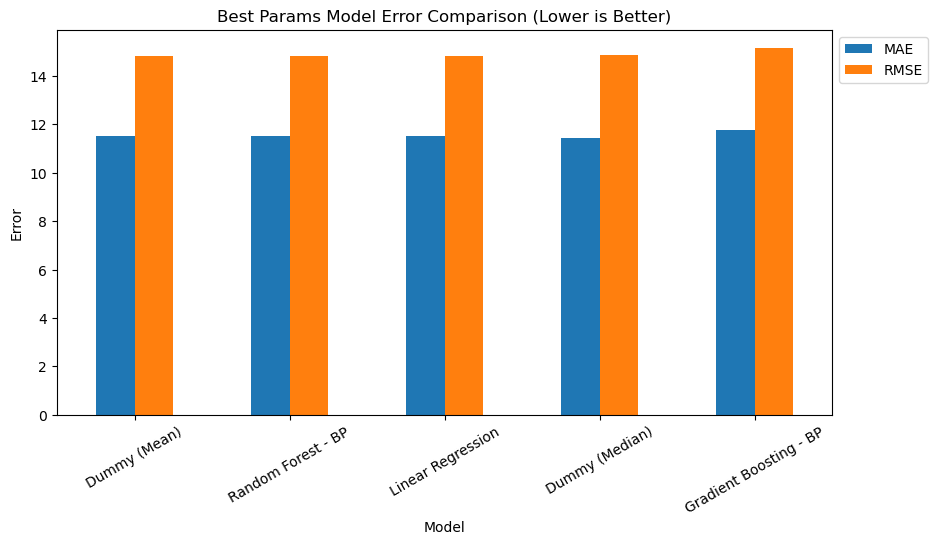

In [41]:
ax = results_df_2.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar", figsize=(10,5))
ax.set_title("Best Params Model Error Comparison (Lower is Better)")
ax.set_ylabel("Error")
ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
ax.tick_params(axis='x', rotation=30)

## All Model Comp

In [43]:
results_df_all = pd.DataFrame([
    dummy_mean_metrics,
    dummy_median_metrics,
    lr_metrics,
    rf_metrics,
    gb_metrics,
    rf_metrics_2,
    gb_metrics_2
]).sort_values(by="RMSE")

print("All Model Comp to Dummy Model")
results_df_all

All Model Comp to Dummy Model


,Model,R2,MAE,RMSE
0,Dummy (Mean),-0.000097,11.512126,14.826212
5,Random Forest - BP,-0.000753,11.519009,14.831073
2,Linear Regression,-0.000924,11.515795,14.832340
4,Gradient Boosting,-0.003130,11.530684,14.848673
1,Dummy (Median),-0.007459,11.455653,14.880678
3,Random Forest,-0.013791,11.639644,14.927369
6,Gradient Boosting - BP,-0.044528,11.788452,15.151972


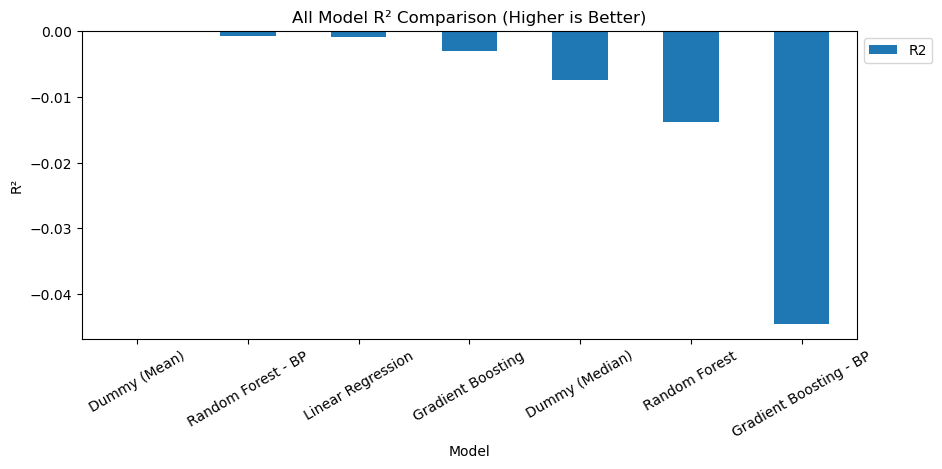

In [50]:
ax = results_df_all.set_index("Model")[["R2"]].plot(kind="bar", figsize=(10,4))
ax.set_title("All Model R² Comparison (Higher is Better)")
ax.set_ylabel("R²")
ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
ax.tick_params(axis='x', rotation=30)

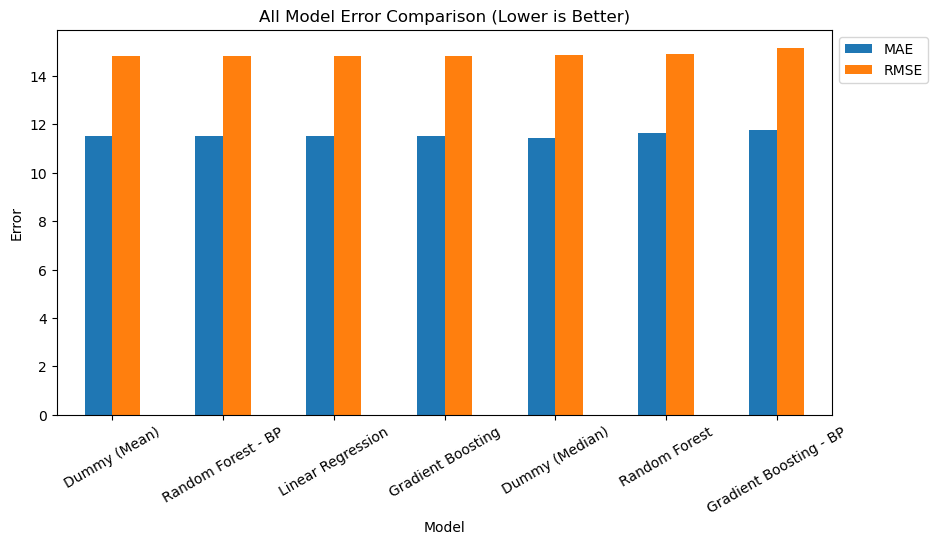

In [44]:
ax = results_df_all.set_index("Model")[["MAE", "RMSE"]].plot(kind="bar", figsize=(10,5))
ax.set_title("All Model Error Comparison (Lower is Better)")
ax.set_ylabel("Error")
ax.legend(bbox_to_anchor=(1.0, 1.0), loc='upper left')
ax.tick_params(axis='x', rotation=30)

# Conclusion

To evaluate whether the selected audio and metadata features meaningfully predict song popularity, baseline DummyRegressor models (mean and median strategies) were introduced and compared against Linear Regression, Random Forest, and Gradient Boosting models, including tuned (“best parameter”) versions. Across all models, performance metrics were nearly identical to the dummy baselines. R² values were approximately zero or slightly negative for every model, indicating that none of the trained models explained variance in popularity better than simply predicting the average popularity for all songs. Additionally, MAE and RMSE values were extremely similar across models, further demonstrating that more complex algorithms did not reduce prediction error relative to the baseline.

These results suggest that the available pre-release audio and descriptive features do not contain sufficient predictive signal to accurately model song popularity. Despite testing multiple modeling approaches and tuning hyperparameters, no model meaningfully outperformed a naïve baseline. This indicates that song success is likely driven by external factors—such as marketing exposure, artist reputation, playlist placement, and social dynamics—that are not captured within the current dataset.

In [57]:
import json
import sklearn
import datetime


model_metrics_report = {
    "project_name": "Song Success Prediction Model",
    "date_created": str(datetime.datetime.now()),
    "sklearn_version": sklearn.__version__,
    
    "data_information": {
        "total_records": len(X_train_scaled) + len(X_test_scaled),
        "train_size": len(X_train_scaled),
        "test_size": len(X_test_scaled),
        "train_test_split": "80/20",
        "target_variable": "popularity",
        "scaling_method": "StandardScaler (fit on training only)",
        "features_dropped": [
            "track_id",
            "track_name",
            "album_name",
            "duration_mm:ss:ms",
            "latlng",
            "capital",
            "demonym",
            "stream_count",
            "artist_name"
        ]
    },
    
    "models": [
        {
            "model_name": "Dummy (Mean)",
            "model_type": "DummyRegressor",
            "hyperparameters": {"strategy": "mean"},
            "metrics": dummy_mean_metrics,
            "recommended": False
        },
        {
            "model_name": "Dummy (Median)",
            "model_type": "DummyRegressor",
            "hyperparameters": {"strategy": "median"},
            "metrics": dummy_median_metrics,
            "recommended": False
        },
        {
            "model_name": "Linear Regression",
            "model_type": "LinearRegression",
            "hyperparameters": lr.get_params(),
            "metrics": lr_metrics,
            "recommended": False
        },
        {
            "model_name": "Random Forest",
            "model_type": "RandomForestRegressor",
            "hyperparameters": rf.get_params(),
            "metrics": rf_metrics,
            "recommended": False
        },
        {
            "model_name": "Random Forest - Best Params",
            "model_type": "RandomForestRegressor",
            "hyperparameters": rf2.get_params(),
            "metrics": rf_metrics_2,
            "recommended": False
        },
        {
            "model_name": "Gradient Boosting",
            "model_type": "GradientBoostingRegressor",
            "hyperparameters": gb.get_params(),
            "metrics": gb_metrics,
            "recommended": False
        },
        {
            "model_name": "Gradient Boosting - Best Params",
            "model_type": "GradientBoostingRegressor",
            "hyperparameters": gb2.get_params(),
            "metrics": gb_metrics_2,
            "recommended": False
        }
    ],
    
    "final_determination": {
        "usable_model_found": False,
        "reason": "All trained models performed similarly to or worse than the Dummy baseline. R² values near zero or negative indicate insufficient predictive signal in the feature set."
    }
}

In [58]:
with open("outputs/model_metrics.json", "w") as f:
    json.dump(model_metrics_report, f, indent=4)